# Which Agent Memory Approach Is Best for Long Conversations?

This notebook builds a practical long-conversation memory workflow using **Oracle AI Database** as the durable memory layer.

The core answer is: **use hybrid layered memory**. Keep recent turns available, summarize older dialogue, retrieve relevant historical context, store stable facts in structured memory, preserve important events as episodic memory, and let a memory manager assemble the context for each turn.

Long conversations are not just long prompts. They are continuity problems.

## Key Takeaways

- Bigger context windows help, but they do not replace memory architecture.
- Sliding window memory keeps recent turns close, but older context falls out.
- Summaries compress older dialogue, but they can drift or lose details.
- Vector retrieval finds semantically related memory, but similarity is not always relevance.
- Structured memory is best for stable facts, preferences, entities, decisions, and state.
- Episodic memory preserves what happened, what was tried, and why it mattered.
- A memory manager coordinates what gets stored, updated, retrieved, summarized, and passed to the model.
- Oracle AI Database is a natural fit when long-conversation memory needs durable storage, SQL precision, vector retrieval, JSON metadata, and governed access.

## Architecture at a Glance

<div style="display:flex; justify-content:center;">

```text
┌──────────────────────────────────────────────────────────────────────┐
│                         User / Agent Turn                             │
│      "Earlier we debugged this issue. What did we decide?"            │
└───────────────────────────────┬──────────────────────────────────────┘
                                │
                                ▼
┌──────────────────────────────────────────────────────────────────────┐
│                          Memory Manager                               │
│  decides what to store, update, retrieve, summarize, and pass forward │
└──────────────┬──────────────┬──────────────┬──────────────┬──────────┘
               │              │              │              │
               ▼              ▼              ▼              ▼
      ┌────────────────┐ ┌───────────┐ ┌─────────────┐ ┌──────────────┐
      │ Recent Context │ │ Summaries │ │ Structured  │ │ Episodic Logs │
      │ last N turns   │ │ old turns │ │ facts/state │ │ events/results│
      └───────┬────────┘ └─────┬─────┘ └──────┬──────┘ └──────┬───────┘
              │                │              │               │
              └────────────────┴──────┬───────┴───────────────┘
                                      ▼
┌──────────────────────────────────────────────────────────────────────┐
│                         Oracle AI Database                            │
│     relational memory + JSON metadata + vector-searchable chunks      │
└──────────────────────────────────┬───────────────────────────────────┘
                                   │
                                   ▼
┌──────────────────────────────────────────────────────────────────────┐
│                           Grounded Answer                             │
│       answer from retrieved evidence, facts, decisions, and events     │
└──────────────────────────────────────────────────────────────────────┘
```

</div>

## What You Will Build

1. Store every conversation turn in Oracle AI Database.
2. Create a rolling summary for older dialogue.
3. Store structured memory for decisions, facts, preferences, metrics, and state.
4. Store episodic memory for important events, outcomes, and prior attempts.
5. Store retrieval chunks and run search over long-term memory.
6. Assemble a context package with a memory manager.
7. Answer: **"Earlier we debugged this issue. What did we decide, and what should I try next?"**
8. Show where Oracle AI Agent Memory and LangChain fit after the core pattern works.

## Memory Approaches Compared

| Memory approach | Best for | Weakness |
|---|---|---|
| Recent context | Immediate continuity and local coherence | Older context falls out |
| Rolling summary | Compressing older dialogue | Can lose details or drift |
| Vector retrieval | Finding semantically related past context | Similarity is not always relevance |
| Structured memory | Facts, preferences, entities, decisions, state | Requires extraction and update rules |
| Episodic memory | Events, outcomes, prior attempts, task resumption | Needs importance scoring and pruning |
| Memory manager | Coordinating what to store, retrieve, and pass to the model | Adds application logic that must be tested |

## What To Use When

| Scenario | Recommended approach |
|---|---|
| Short chats | Recent context |
| Long linear chats | Recent context + rolling summaries |
| Recall across sessions | Vector retrieval |
| Correct preferences and profile facts | Structured memory |
| Task resumption | Episodic memory |
| Durable, governed continuity | Hybrid layered memory with a memory manager |

## Prerequisites

You should have:

- Python 3.10+
- Oracle AI Database access
- `oracledb`, `python-dotenv`, `pandas`, `numpy`, `scikit-learn`, and LangChain packages installed
- Optional: Oracle AI Agent Memory package

The notebook uses `.env` values from the project root:

```env
ORACLE_USER=
ORACLE_PASSWORD=
ORACLE_DSN=
ORACLE_CONFIG_DIR=
ORACLE_WALLET_LOCATION=
ORACLE_WALLET_PASSWORD=
```

If you use a wallet, set the wallet fields. If your connection uses a simple DSN, `ORACLE_USER`, `ORACLE_PASSWORD`, and `ORACLE_DSN` are enough.

In [1]:
# Install dependencies (safe to re-run)
import sys
import subprocess
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / ".env").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
requirements_path = PROJECT_ROOT / "requirements.txt"

if requirements_path.exists():
    command = [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)]
else:
    command = [
        sys.executable, "-m", "pip", "install", "-q",
        "oracledb", "python-dotenv", "pandas", "numpy", "scikit-learn",
        "matplotlib", "langchain", "langchain-core", "langchain-oracledb", "ipykernel"
    ]

result = subprocess.run(command, capture_output=True, text=True)
if result.returncode != 0:
    print("Dependency installation failed. Last pip messages:")
    print((result.stderr or result.stdout)[-2000:])
    raise RuntimeError("Dependency installation failed.")

print("Dependencies are installed.")

Dependencies are installed.


## Configuration

This section loads `.env`, masks sensitive values, and validates whether the notebook can run the Oracle-backed workflow.

In [2]:
import os
import json
import hashlib
from array import array
from datetime import datetime, timedelta
from importlib import metadata
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import oracledb


ENV_PATH = PROJECT_ROOT / ".env"
load_dotenv(ENV_PATH)

CONFIG = {
    "ORACLE_USER": os.getenv("ORACLE_USER", "").strip(),
    "ORACLE_PASSWORD": os.getenv("ORACLE_PASSWORD", ""),
    "ORACLE_DSN": os.getenv("ORACLE_DSN", "").strip(),
    "ORACLE_CONFIG_DIR": os.getenv("ORACLE_CONFIG_DIR", "").strip() or os.getenv("TNS_ADMIN", "").strip(),
    "ORACLE_WALLET_LOCATION": os.getenv("ORACLE_WALLET_LOCATION", "").strip(),
    "ORACLE_WALLET_PASSWORD": os.getenv("ORACLE_WALLET_PASSWORD", ""),
}


def mask(value: str) -> str:
    if not value:
        return ""
    if len(value) <= 4:
        return "****"
    return value[:2] + "..." + value[-2:]


config_readiness = pd.DataFrame(
    [
        {"setting": "ORACLE_USER", "status": "READY" if CONFIG["ORACLE_USER"] else "ACTION_NEEDED", "value": mask(CONFIG["ORACLE_USER"])},
        {"setting": "ORACLE_PASSWORD", "status": "READY" if CONFIG["ORACLE_PASSWORD"] else "ACTION_NEEDED", "value": "****" if CONFIG["ORACLE_PASSWORD"] else ""},
        {"setting": "ORACLE_DSN", "status": "READY" if CONFIG["ORACLE_DSN"] else "ACTION_NEEDED", "value": mask(CONFIG["ORACLE_DSN"])},
        {"setting": "ORACLE_CONFIG_DIR", "status": "OPTIONAL" if not CONFIG["ORACLE_CONFIG_DIR"] else "READY", "value": CONFIG["ORACLE_CONFIG_DIR"]},
        {"setting": "ORACLE_WALLET_LOCATION", "status": "OPTIONAL" if not CONFIG["ORACLE_WALLET_LOCATION"] else "READY", "value": CONFIG["ORACLE_WALLET_LOCATION"]},
    ]
)

config_readiness

,setting,status,value
0,ORACLE_USER,READY,te...er
1,ORACLE_PASSWORD,READY,****
2,ORACLE_DSN,READY,lo...B1
3,ORACLE_CONFIG_DIR,OPTIONAL,
4,ORACLE_WALLET_LOCATION,OPTIONAL,


## Step 1 - Connect to Oracle AI Database

This notebook intentionally requires Oracle AI Database for the main workflow. The memory layers should be written to and read back from the database so the output is real, not only local simulation.

In [3]:
required_settings = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing = [key for key in required_settings if not CONFIG[key]]
if missing:
    raise RuntimeError(f"Missing required Oracle settings in .env: {missing}")

connect_kwargs = {
    "user": CONFIG["ORACLE_USER"],
    "password": CONFIG["ORACLE_PASSWORD"],
    "dsn": CONFIG["ORACLE_DSN"],
}
if CONFIG["ORACLE_CONFIG_DIR"]:
    connect_kwargs["config_dir"] = CONFIG["ORACLE_CONFIG_DIR"]
if CONFIG["ORACLE_WALLET_LOCATION"]:
    connect_kwargs["wallet_location"] = CONFIG["ORACLE_WALLET_LOCATION"]
if CONFIG["ORACLE_WALLET_PASSWORD"]:
    connect_kwargs["wallet_password"] = CONFIG["ORACLE_WALLET_PASSWORD"]

connection = oracledb.connect(**connect_kwargs)
connection.autocommit = False
cursor = connection.cursor()

db_info = cursor.execute(
    "SELECT USER, sys_context('USERENV', 'DB_NAME') FROM dual"
).fetchone()

print("Connected to Oracle AI Database successfully.")

Connected to Oracle AI Database successfully.


## Helper Utilities

These helpers keep the rest of the notebook short and safe to rerun.

In [4]:
THREAD_ID = "checkout-debug-042"
TABLE_PREFIX = "LCAM"


def read_oracle_value(value):
    # python-oracledb returns CLOB columns as LOB objects in some modes.
    # Convert them once here so downstream pandas/sklearn code receives plain strings.
    if hasattr(value, "read"):
        return value.read()
    return value


def fetch_df(sql: str, params: dict | None = None) -> pd.DataFrame:
    cursor.execute(sql, params or {})
    columns = [col[0].lower() for col in cursor.description]
    rows = [
        [read_oracle_value(value) for value in row]
        for row in cursor.fetchall()
    ]
    return pd.DataFrame(rows, columns=columns)


def drop_table_if_exists(table_name: str):
    try:
        cursor.execute(f"DROP TABLE {table_name} PURGE")
    except Exception as exc:
        error = getattr(exc, "args", [None])[0]
        code = getattr(error, "code", None)
        if code != 942:
            raise


def deterministic_embedding(text: str, dimensions: int = 64) -> np.ndarray:
    vector = np.zeros(dimensions, dtype=np.float32)
    for token in text.lower().split():
        clean = token.strip(".,:;!?()[]{}")
        if not clean:
            continue
        digest = hashlib.sha256(clean.encode("utf-8")).digest()
        index = int.from_bytes(digest[:4], "little") % dimensions
        vector[index] += 1.0 if digest[4] % 2 == 0 else -1.0
    norm = np.linalg.norm(vector)
    return vector / norm if norm else vector


def as_oracle_vector(values: np.ndarray) -> array:
    return array("f", [float(v) for v in values.astype(np.float32)])


print("Helper utilities loaded.")

Helper utilities loaded.


## Step 2 - Create the Long Conversation Dataset

The demo uses one long debugging thread. It includes the details Wojtek called out: raw conversation history, summaries, vector-searchable chunks, structured facts, episodic logs, and a final context assembly step.

In [5]:
base_time = datetime(2026, 5, 14, 10, 0, 0)

turns = [
    ("user", "We are seeing intermittent checkout failures after the payment service deployment."),
    ("assistant", "Let's identify whether failures come from payment authorization, inventory reservation, or order creation."),
    ("user", "The error is HTTP 409 during inventory reservation, but only for EU customers."),
    ("assistant", "A 409 suggests a conflicting reservation state. Let's inspect recent inventory changes and region flags."),
    ("user", "We changed the inventory lock timeout from 30 seconds to 5 seconds yesterday."),
    ("assistant", "That timeout change is a strong suspect. Shorter locks can expire while payment authorization is pending."),
    ("user", "The team prefers not to roll back unless we can prove it is causing the issue."),
    ("assistant", "Good constraint. Compare failures before and after the timeout change and segment by region."),
    ("user", "EU failures started after the timeout change. US traffic looks normal."),
    ("assistant", "That points to a region-specific timing issue."),
    ("user", "EU payment authorization has p95 latency around 7 seconds."),
    ("assistant", "Then a 5 second inventory lock can expire before authorization completes."),
    ("user", "We decided to set inventory_lock_timeout_seconds to 12 for EU only and keep 5 for US."),
    ("assistant", "Decision recorded: use a region-specific timeout, 12 seconds for EU and 5 seconds for US."),
    ("user", "Please remember that we should add a metric for expired inventory locks by region."),
    ("assistant", "Noted. Track expired inventory locks by region."),
    ("user", "The first patch accidentally applied 12 seconds globally, so we reverted it."),
    ("assistant", "Important prior attempt: global timeout change was reverted because it affected all regions."),
    ("user", "The second patch added the EU-only config and passed staging tests."),
    ("assistant", "The EU-only timeout patch passed staging. Next step is a small rollout with monitoring."),
    ("user", "For rollout, we agreed to enable it for 10 percent of EU traffic first."),
    ("assistant", "Rollout plan recorded: start with 10 percent of EU traffic and monitor lock-expiry and checkout success metrics."),
    ("user", "Can you switch topics and help me outline the release notes?"),
    ("assistant", "Sure. Release notes should mention EU checkout reliability improvements and inventory reservation timing adjustments."),
    ("user", "Also, my preference is concise release notes with a technical appendix."),
    ("assistant", "Preference recorded: concise release notes plus a technical appendix."),
]

conversation_df = pd.DataFrame(
    {
        "thread_id": THREAD_ID,
        "turn_id": idx + 1,
        "role": role,
        "content": content,
        "metadata_json": json.dumps({"demo": "long_conversation_memory"}),
        "created_at": base_time + timedelta(minutes=idx * 3),
    }
    for idx, (role, content) in enumerate(turns)
)

conversation_df.tail(6)

,thread_id,turn_id,role,content,metadata_json,created_at
20,checkout-debug-042,21,user,"For rollout, we agreed to enable it for 10 per...","{""demo"": ""long_conversation_memory""}",2026-05-14 11:00:00
21,checkout-debug-042,22,assistant,Rollout plan recorded: start with 10 percent o...,"{""demo"": ""long_conversation_memory""}",2026-05-14 11:03:00
22,checkout-debug-042,23,user,Can you switch topics and help me outline the ...,"{""demo"": ""long_conversation_memory""}",2026-05-14 11:06:00
23,checkout-debug-042,24,assistant,Sure. Release notes should mention EU checkout...,"{""demo"": ""long_conversation_memory""}",2026-05-14 11:09:00
24,checkout-debug-042,25,user,"Also, my preference is concise release notes w...","{""demo"": ""long_conversation_memory""}",2026-05-14 11:12:00
25,checkout-debug-042,26,assistant,Preference recorded: concise release notes plu...,"{""demo"": ""long_conversation_memory""}",2026-05-14 11:15:00


## Step 3 - Create Oracle Memory Tables

The schema is intentionally simple and visible:

- `LCAM_CONVERSATION_MEMORY` stores every turn.
- `LCAM_THREAD_SUMMARIES` stores rolling summaries.
- `LCAM_STRUCTURED_MEMORY` stores stable facts, decisions, preferences, metrics, and state.
- `LCAM_EPISODIC_MEMORY` stores events, outcomes, and prior attempts.
- `LCAM_MEMORY_CHUNKS` stores retrieval-ready memory chunks.
- `LCAM_VECTOR_MEMORY` is created only if the connected database supports vector columns.

In [6]:
tables = [
    "LCAM_VECTOR_MEMORY",
    "LCAM_MEMORY_CHUNKS",
    "LCAM_EPISODIC_MEMORY",
    "LCAM_STRUCTURED_MEMORY",
    "LCAM_THREAD_SUMMARIES",
    "LCAM_CONVERSATION_MEMORY",
]

for table in tables:
    drop_table_if_exists(table)

cursor.execute("""
CREATE TABLE lcam_conversation_memory (
    thread_id      VARCHAR2(100),
    turn_id        NUMBER,
    role           VARCHAR2(20),
    content        CLOB,
    metadata_json  CLOB,
    created_at     TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE lcam_thread_summaries (
    thread_id      VARCHAR2(100) PRIMARY KEY,
    summary        CLOB,
    covered_turns  NUMBER,
    updated_at     TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE lcam_structured_memory (
    thread_id       VARCHAR2(100),
    memory_type     VARCHAR2(50),
    memory_key      VARCHAR2(200),
    memory_value    CLOB,
    scope_json      CLOB,
    source_turn_id  NUMBER,
    updated_at      TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE lcam_episodic_memory (
    event_id    VARCHAR2(100) PRIMARY KEY,
    thread_id   VARCHAR2(100),
    event        VARCHAR2(500),
    outcome      CLOB,
    importance   NUMBER,
    created_at   TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE lcam_memory_chunks (
    chunk_id       VARCHAR2(100) PRIMARY KEY,
    thread_id      VARCHAR2(100),
    source         VARCHAR2(50),
    text           CLOB,
    metadata_json  CLOB,
    created_at     TIMESTAMP DEFAULT SYSTIMESTAMP
)
""")

connection.commit()
print("Oracle memory tables created.")

Oracle memory tables created.


## Step 4 - Store Every Message in Conversational Memory

This is the raw history layer. It is useful for auditability and deterministic reconstruction, but it should not be passed wholesale into every model request.

In [7]:
# Make this cell safe to rerun independently.
cursor.execute(
    "DELETE FROM lcam_conversation_memory WHERE thread_id = :thread_id",
    {"thread_id": THREAD_ID},
)

cursor.executemany(
    """
    INSERT INTO lcam_conversation_memory
    (thread_id, turn_id, role, content, metadata_json, created_at)
    VALUES (:thread_id, :turn_id, :role, :content, :metadata_json, :created_at)
    """,
    conversation_df.to_dict(orient="records"),
)
connection.commit()

fetch_df("""
SELECT thread_id, COUNT(*) AS turn_count, MIN(created_at) AS first_turn, MAX(created_at) AS last_turn
FROM lcam_conversation_memory
GROUP BY thread_id
""")

,thread_id,turn_count,first_turn,last_turn
0,checkout-debug-042,26,2026-05-14 10:00:00,2026-05-14 11:15:00


## Step 5 - Create Recent Context and a Rolling Summary

Recent context keeps the current exchange coherent. The rolling summary compresses older dialogue so the model can recover continuity without receiving every old message.

In [8]:
recent_context = fetch_df("""
SELECT turn_id, role, content
FROM lcam_conversation_memory
WHERE thread_id = :thread_id
ORDER BY turn_id DESC
FETCH FIRST 6 ROWS ONLY
""", {"thread_id": THREAD_ID}).sort_values("turn_id")

rolling_summary = (
    "Checkout failures appeared as HTTP 409 conflicts during inventory reservation. "
    "The issue was isolated to EU traffic while US traffic looked normal. "
    "The inventory lock timeout had been reduced from 30 seconds to 5 seconds. "
    "EU payment authorization p95 latency was around 7 seconds, longer than the 5 second lock. "
    "The team decided on a region-specific timeout: 12 seconds for EU and 5 seconds for US."
)

# Make this cell safe to rerun independently.
cursor.execute(
    "DELETE FROM lcam_thread_summaries WHERE thread_id = :thread_id",
    {"thread_id": THREAD_ID},
)

cursor.execute(
    """
    INSERT INTO lcam_thread_summaries
    (thread_id, summary, covered_turns, updated_at)
    VALUES (:1, :2, :3, SYSTIMESTAMP)
    """,
    [THREAD_ID, rolling_summary, len(conversation_df) - len(recent_context)],
)
connection.commit()

display(recent_context)
print(rolling_summary)

,turn_id,role,content
5,21,user,"For rollout, we agreed to enable it for 10 per..."
4,22,assistant,Rollout plan recorded: start with 10 percent o...
3,23,user,Can you switch topics and help me outline the ...
2,24,assistant,Sure. Release notes should mention EU checkout...
1,25,user,"Also, my preference is concise release notes w..."
0,26,assistant,Preference recorded: concise release notes plu...


Checkout failures appeared as HTTP 409 conflicts during inventory reservation. The issue was isolated to EU traffic while US traffic looked normal. The inventory lock timeout had been reduced from 30 seconds to 5 seconds. EU payment authorization p95 latency was around 7 seconds, longer than the 5 second lock. The team decided on a region-specific timeout: 12 seconds for EU and 5 seconds for US.


## Step 6 - Store Structured Memory

Structured memory is where exactness matters. It captures stable facts and state that should survive long conversations and future sessions.

In [9]:
structured_rows = [
    (THREAD_ID, "decision", "inventory_timeout_strategy", "Use region-specific inventory lock timeout: EU=12 seconds, US=5 seconds.", {"region": ["EU", "US"]}, 13),
    (THREAD_ID, "project_state", "suspected_root_cause", "EU payment authorization p95 latency exceeded the 5 second inventory lock timeout.", {"service": "payment"}, 11),
    (THREAD_ID, "metric", "monitoring_metric", "Track expired inventory locks by region.", {"owner": "checkout_platform"}, 15),
    (THREAD_ID, "preference", "release_notes_style", "Keep release notes concise and include a technical appendix.", {"artifact": "release_notes"}, 25),
]

# Make this cell safe to rerun independently.
cursor.execute(
    "DELETE FROM lcam_structured_memory WHERE thread_id = :thread_id",
    {"thread_id": THREAD_ID},
)

cursor.executemany(
    """
    INSERT INTO lcam_structured_memory
    (thread_id, memory_type, memory_key, memory_value, scope_json, source_turn_id, updated_at)
    VALUES (:1, :2, :3, :4, :5, :6, SYSTIMESTAMP)
    """,
    [(t, mt, k, v, json.dumps(scope), turn) for t, mt, k, v, scope, turn in structured_rows],
)
connection.commit()

fetch_df("""
SELECT memory_type, memory_key, memory_value, source_turn_id
FROM lcam_structured_memory
WHERE thread_id = :thread_id
ORDER BY memory_type, memory_key
""", {"thread_id": THREAD_ID})

,memory_type,memory_key,memory_value,source_turn_id
0,decision,inventory_timeout_strategy,Use region-specific inventory lock timeout: EU...,13
1,metric,monitoring_metric,Track expired inventory locks by region.,15
2,preference,release_notes_style,Keep release notes concise and include a techn...,25
3,project_state,suspected_root_cause,EU payment authorization p95 latency exceeded ...,11


## Step 7 - Store Episodic Memory

Episodic memory records what happened and why it mattered. This helps an agent resume work and avoid repeating failed attempts.

In [10]:
episodic_rows = [
    ("evt-001", THREAD_ID, "Timeout change suspected", "EU failures correlated with reducing inventory lock timeout from 30s to 5s.", 0.82, base_time + timedelta(minutes=30)),
    ("evt-002", THREAD_ID, "Global patch reverted", "Applying 12s globally was rejected because the fix should only affect EU traffic.", 0.91, base_time + timedelta(minutes=48)),
    ("evt-003", THREAD_ID, "EU-only patch passed staging", "Second patch added EU-only config and passed staging validation.", 0.93, base_time + timedelta(minutes=54)),
    ("evt-004", THREAD_ID, "Rollout plan agreed", "Enable for 10 percent of EU traffic first, then monitor checkout success and lock expiry.", 0.88, base_time + timedelta(minutes=60)),
]

# Make this cell safe to rerun independently.
cursor.execute(
    "DELETE FROM lcam_episodic_memory WHERE thread_id = :thread_id",
    {"thread_id": THREAD_ID},
)

cursor.executemany(
    """
    INSERT INTO lcam_episodic_memory
    (event_id, thread_id, event, outcome, importance, created_at)
    VALUES (:1, :2, :3, :4, :5, :6)
    """,
    episodic_rows,
)
connection.commit()

fetch_df("""
SELECT event, outcome, importance
FROM lcam_episodic_memory
WHERE thread_id = :thread_id
ORDER BY importance DESC
""", {"thread_id": THREAD_ID})

,event,outcome,importance
0,EU-only patch passed staging,Second patch added EU-only config and passed s...,0.93
1,Global patch reverted,Applying 12s globally was rejected because the...,0.91
2,Rollout plan agreed,"Enable for 10 percent of EU traffic first, the...",0.88
3,Timeout change suspected,EU failures correlated with reducing inventory...,0.82


## Step 8 - Store Retrieval Chunks

Retrieval chunks provide the long-term recall layer. The chunks include raw conversation turns, structured memory, and episodic memory so retrieval can find context across memory types.

In [11]:
conversation_chunks = fetch_df("""
SELECT 'msg-' || LPAD(turn_id, 3, '0') AS chunk_id,
       thread_id,
       'conversation' AS source,
       content AS text,
       metadata_json
FROM lcam_conversation_memory
WHERE thread_id = :thread_id
""", {"thread_id": THREAD_ID})

structured_chunks = fetch_df("""
SELECT 'fact-' || ROW_NUMBER() OVER (ORDER BY memory_type, memory_key) AS chunk_id,
       thread_id,
       'structured_memory' AS source,
       memory_type || ': ' || memory_key || ': ' || memory_value AS text,
       scope_json AS metadata_json
FROM lcam_structured_memory
WHERE thread_id = :thread_id
""", {"thread_id": THREAD_ID})

episodic_chunks = fetch_df("""
SELECT event_id AS chunk_id,
       thread_id,
       'episodic_memory' AS source,
       event || ': ' || outcome AS text,
       JSON_OBJECT('importance' VALUE importance) AS metadata_json
FROM lcam_episodic_memory
WHERE thread_id = :thread_id
""", {"thread_id": THREAD_ID})

memory_chunks = pd.concat([conversation_chunks, structured_chunks, episodic_chunks], ignore_index=True)

# Make this cell safe to rerun independently.
cursor.execute(
    "DELETE FROM lcam_memory_chunks WHERE thread_id = :thread_id",
    {"thread_id": THREAD_ID},
)

cursor.executemany(
    """
    INSERT INTO lcam_memory_chunks
    (chunk_id, thread_id, source, text, metadata_json)
    VALUES (:chunk_id, :thread_id, :source, :text, :metadata_json)
    """,
    memory_chunks.to_dict(orient="records"),
)
connection.commit()

fetch_df("SELECT source, COUNT(*) AS chunks FROM lcam_memory_chunks GROUP BY source ORDER BY source")

,source,chunks
0,conversation,26
1,episodic_memory,4
2,structured_memory,4


## Memory Layers Stored in Oracle

This chart gives a quick sanity check that the notebook wrote all memory layers into Oracle AI Database before retrieval begins.

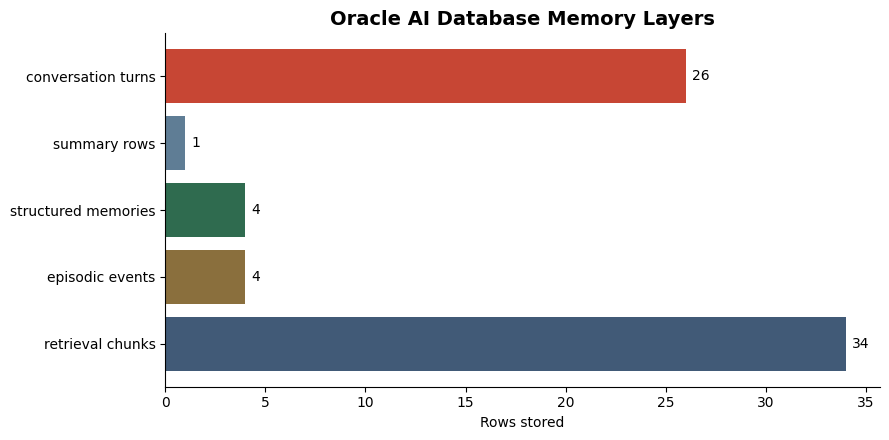

,layer,rows
0,conversation turns,26
1,summary rows,1
2,structured memories,4
3,episodic events,4
4,retrieval chunks,34


In [12]:
layer_counts = pd.DataFrame(
    [
        {"layer": "conversation turns", "rows": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_conversation_memory")["count"].iloc[0])},
        {"layer": "summary rows", "rows": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_thread_summaries")["count"].iloc[0])},
        {"layer": "structured memories", "rows": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_structured_memory")["count"].iloc[0])},
        {"layer": "episodic events", "rows": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_episodic_memory")["count"].iloc[0])},
        {"layer": "retrieval chunks", "rows": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_memory_chunks")["count"].iloc[0])},
    ]
)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#C74634", "#5F7D95", "#2F6B4F", "#8A6F3D", "#415A77"]
ax.barh(layer_counts["layer"], layer_counts["rows"], color=colors)
ax.set_title("Oracle AI Database Memory Layers", fontsize=14, weight="bold")
ax.set_xlabel("Rows stored")
ax.invert_yaxis()
for i, value in enumerate(layer_counts["rows"]):
    ax.text(value + 0.3, i, str(value), va="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

layer_counts

## Step 9 - Retrieval over Oracle-Stored Memory

This cell ranks chunks that were read from Oracle AI Database. It uses deterministic TF-IDF ranking so the notebook does not require an external embedding API.

In [13]:
FOLLOW_UP_QUESTION = "Earlier we debugged this issue. What did we decide, and what should I try next?"

oracle_chunks = fetch_df("""
SELECT chunk_id, source, text
FROM lcam_memory_chunks
WHERE thread_id = :thread_id
""", {"thread_id": THREAD_ID})

oracle_chunks["text"] = oracle_chunks["text"].astype(str)

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
matrix = vectorizer.fit_transform(oracle_chunks["text"])
scores = cosine_similarity(vectorizer.transform([FOLLOW_UP_QUESTION]), matrix).ravel()

top_indices = np.argsort(scores)[::-1][:6]
retrieved_memory = oracle_chunks.iloc[top_indices].copy()
retrieved_memory["score"] = scores[top_indices]
retrieved_memory[["chunk_id", "source", "score", "text"]].copy()

,chunk_id,source,score,text
28,msg-010,conversation,0.330775,That points to a region-specific timing issue.
25,msg-007,conversation,0.250155,The team prefers not to roll back unless we ca...
32,msg-014,conversation,0.000000,Decision recorded: use a region-specific timeo...
33,msg-015,conversation,0.000000,Please remember that we should add a metric fo...
30,msg-012,conversation,0.000000,Then a 5 second inventory lock can expire befo...
31,msg-013,conversation,0.000000,We decided to set inventory_lock_timeout_secon...


## Retrieved Memory Scores

This chart makes the retrieval step easier to inspect. It shows which memory chunks were selected for the follow-up question.

,chunk_id,source,score,text
33,msg-015,conversation,0.000000,Please remember that we should add a metric fo...
32,msg-014,conversation,0.000000,Decision recorded: use a region-specific timeo...
31,msg-013,conversation,0.000000,We decided to set inventory_lock_timeout_secon...
30,msg-012,conversation,0.000000,Then a 5 second inventory lock can expire befo...
25,msg-007,conversation,0.250155,The team prefers not to roll back unless we ca...
28,msg-010,conversation,0.330775,That points to a region-specific timing issue.


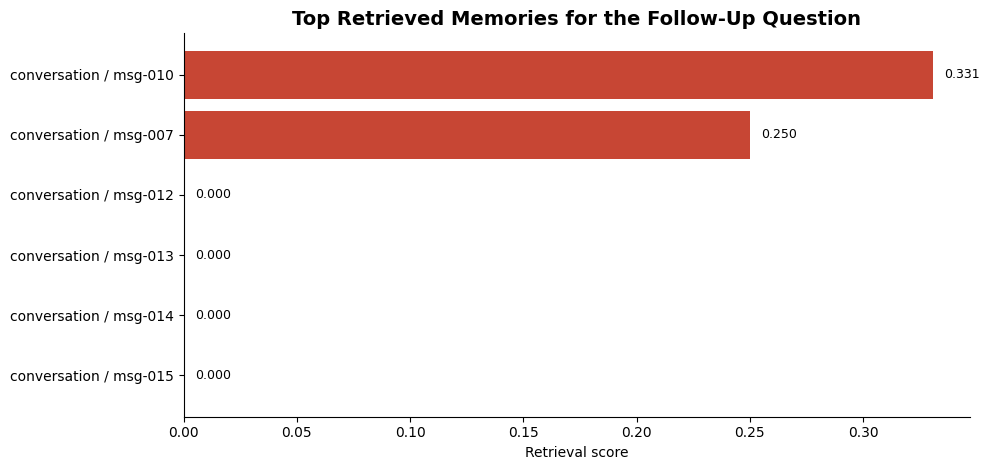

In [14]:
score_plot = retrieved_memory[["chunk_id", "source", "score", "text"]].copy()
score_plot["label"] = score_plot["source"] + " / " + score_plot["chunk_id"]
score_plot = score_plot.sort_values("score", ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(score_plot["label"], score_plot["score"], color="#C74634")
ax.set_title("Top Retrieved Memories for the Follow-Up Question", fontsize=14, weight="bold")
ax.set_xlabel("Retrieval score")
ax.spines[["top", "right"]].set_visible(False)
for i, value in enumerate(score_plot["score"]):
    ax.text(value + 0.005, i, f"{value:.3f}", va="center", fontsize=9)
plt.tight_layout()

score_plot[["chunk_id", "source", "score", "text"]]

## Step 10 - Optional Oracle Native Vector Search

If the connected Oracle AI Database supports the `VECTOR` data type, this section creates a vector-searchable table and runs `VECTOR_DISTANCE`. If not, the notebook keeps the Oracle-stored chunk retrieval results from the previous step.

In [15]:
VECTOR_DIMENSIONS = 64
vector_status = {"status": "SKIPPED", "message": "Vector table not created yet"}

try:
    drop_table_if_exists("LCAM_VECTOR_MEMORY")
    cursor.execute(f"""
    CREATE TABLE lcam_vector_memory (
        chunk_id       VARCHAR2(100) PRIMARY KEY,
        thread_id      VARCHAR2(100),
        source         VARCHAR2(50),
        text           CLOB,
        embedding      VECTOR({VECTOR_DIMENSIONS}, FLOAT32)
    )
    """)

    cursor.executemany(
        """
        INSERT INTO lcam_vector_memory
        (chunk_id, thread_id, source, text, embedding)
        VALUES (:1, :2, :3, :4, :5)
        """,
        [
            (row.chunk_id, row.thread_id, row.source, row.text, as_oracle_vector(deterministic_embedding(row.text)))
            for row in memory_chunks.itertuples()
        ],
    )
    connection.commit()
    vector_status = {"status": "READY", "message": "LCAM_VECTOR_MEMORY created and populated."}
except Exception as exc:
    connection.rollback()
    vector_status = {"status": "NOT_AVAILABLE", "message": f"{type(exc).__name__}: {exc}"}

vector_status

{'status': 'READY', 'message': 'LCAM_VECTOR_MEMORY created and populated.'}

In [16]:
if vector_status["status"] == "READY":
    query_embedding = as_oracle_vector(deterministic_embedding(FOLLOW_UP_QUESTION))
    retrieved_memory = fetch_df("""
    SELECT chunk_id,
           source,
           1 - VECTOR_DISTANCE(embedding, :query_embedding, COSINE) AS score,
           text
    FROM lcam_vector_memory
    WHERE thread_id = :thread_id
    ORDER BY VECTOR_DISTANCE(embedding, :query_embedding, COSINE)
    FETCH FIRST 6 ROWS ONLY
    """, {"query_embedding": query_embedding, "thread_id": THREAD_ID})
    retrieval_mode = "Oracle VECTOR_DISTANCE"
else:
    retrieval_mode = "Oracle-stored chunks with deterministic TF-IDF ranking"

print(f"Retrieval mode: {retrieval_mode}")
retrieved_memory[["chunk_id", "source", "score", "text"]].copy()

Retrieval mode: Oracle VECTOR_DISTANCE


,chunk_id,source,score,text
0,msg-020,conversation,0.259281,The EU-only timeout patch passed staging. Next...
1,msg-015,conversation,0.210042,Please remember that we should add a metric fo...
2,msg-017,conversation,0.210042,The first patch accidentally applied 12 second...
3,msg-021,conversation,0.181902,"For rollout, we agreed to enable it for 10 per..."
4,msg-014,conversation,0.166924,Decision recorded: use a region-specific timeo...
5,evt-004,episodic_memory,0.162698,Rollout plan agreed: Enable for 10 percent of ...


## Step 11 - Assemble Context with a Memory Manager

The memory manager is the point of the layered architecture. It decides what to retrieve and what to pass to the model for this turn.

In [17]:
def assemble_context(thread_id: str, question: str) -> dict:
    recent = fetch_df("""
    SELECT turn_id, role, content
    FROM lcam_conversation_memory
    WHERE thread_id = :thread_id
    ORDER BY turn_id DESC
    FETCH FIRST 6 ROWS ONLY
    """, {"thread_id": thread_id}).sort_values("turn_id")

    summary = fetch_df("""
    SELECT summary
    FROM lcam_thread_summaries
    WHERE thread_id = :thread_id
    """, {"thread_id": thread_id})["summary"].iloc[0]

    structured = fetch_df("""
    SELECT memory_type, memory_key, memory_value
    FROM lcam_structured_memory
    WHERE thread_id = :thread_id
    ORDER BY memory_type, memory_key
    """, {"thread_id": thread_id})

    episodes = fetch_df("""
    SELECT event, outcome, importance
    FROM lcam_episodic_memory
    WHERE thread_id = :thread_id
    ORDER BY importance DESC
    FETCH FIRST 4 ROWS ONLY
    """, {"thread_id": thread_id})

    return {
        "thread_id": thread_id,
        "question": question,
        "retrieval_mode": retrieval_mode,
        "recent_context": recent.to_dict(orient="records"),
        "rolling_summary": summary,
        "structured_memory": structured.to_dict(orient="records"),
        "episodic_memory": episodes.to_dict(orient="records"),
        "retrieved_memory": retrieved_memory[["source", "score", "text"]].to_dict(orient="records"),
    }


context_package = assemble_context(THREAD_ID, FOLLOW_UP_QUESTION)
print(json.dumps(context_package, indent=2, default=str)[:2800])

{
  "thread_id": "checkout-debug-042",
  "question": "Earlier we debugged this issue. What did we decide, and what should I try next?",
  "retrieval_mode": "Oracle VECTOR_DISTANCE",
  "recent_context": [
    {
      "turn_id": 21,
      "role": "user",
      "content": "For rollout, we agreed to enable it for 10 percent of EU traffic first."
    },
    {
      "turn_id": 22,
      "role": "assistant",
      "content": "Rollout plan recorded: start with 10 percent of EU traffic and monitor lock-expiry and checkout success metrics."
    },
    {
      "turn_id": 23,
      "role": "user",
      "content": "Can you switch topics and help me outline the release notes?"
    },
    {
      "turn_id": 24,
      "role": "assistant",
      "content": "Sure. Release notes should mention EU checkout reliability improvements and inventory reservation timing adjustments."
    },
    {
      "turn_id": 25,
      "role": "user",
      "content": "Also, my preference is concise release notes with a tec

## Step 12 - Build an Evidence Package for the Follow-Up

Instead of pretending a model answered the question, this cell shows the evidence package that would be passed to the model. The short answer draft below is assembled from Oracle-backed facts and events so the output stays deterministic and reviewable.

In [18]:
structured_by_key = {
    item["memory_key"]: item["memory_value"]
    for item in context_package["structured_memory"]
}

evidence_cards = pd.DataFrame(
    [
        {"evidence_type": "root_cause", "value": structured_by_key["suspected_root_cause"]},
        {"evidence_type": "decision", "value": structured_by_key["inventory_timeout_strategy"]},
        {"evidence_type": "metric", "value": structured_by_key["monitoring_metric"]},
        {
            "evidence_type": "prior_attempt",
            "value": "The global 12 second timeout patch was reverted because the fix should only affect EU traffic.",
        },
        {
            "evidence_type": "next_step",
            "value": "Enable the EU-only change for 10 percent of EU traffic and monitor checkout success plus lock expiry.",
        },
    ]
)

answer_draft = (
    "Based on the stored memory, keep the timeout change region-specific: EU uses 12 seconds "
    "and US stays at 5 seconds. Do not retry the global timeout patch; it was already reverted. "
    "Next, roll out the EU-only change to 10 percent of EU traffic and monitor expired inventory locks by region."
)

display(evidence_cards)
print("Question:")
print(FOLLOW_UP_QUESTION)
print("\nAnswer draft from Oracle-backed evidence:")
print(answer_draft)

,evidence_type,value
0,root_cause,EU payment authorization p95 latency exceeded ...
1,decision,Use region-specific inventory lock timeout: EU...
2,metric,Track expired inventory locks by region.
3,prior_attempt,The global 12 second timeout patch was reverte...
4,next_step,Enable the EU-only change for 10 percent of EU...


Question:
Earlier we debugged this issue. What did we decide, and what should I try next?

Answer draft from Oracle-backed evidence:
Based on the stored memory, keep the timeout change region-specific: EU uses 12 seconds and US stays at 5 seconds. Do not retry the global timeout patch; it was already reverted. Next, roll out the EU-only change to 10 percent of EU traffic and monitor expired inventory locks by region.


## Retrieval Playground

Edit `PLAYGROUND_QUESTIONS` and rerun the cell to test follow-up questions against the same Oracle-backed memory. This keeps the section useful without adding another chart.

In [19]:
def retrieve_question(question: str, top_k: int = 5) -> pd.DataFrame:
    chunks = fetch_df("""
    SELECT chunk_id, source, text
    FROM lcam_memory_chunks
    WHERE thread_id = :thread_id
    """, {"thread_id": THREAD_ID})
    chunks["text"] = chunks["text"].astype(str)

    local_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    local_matrix = local_vectorizer.fit_transform(chunks["text"])
    local_scores = cosine_similarity(local_vectorizer.transform([question]), local_matrix).ravel()

    top = np.argsort(local_scores)[::-1][:top_k]
    result = chunks.iloc[top].copy()
    result["score"] = local_scores[top]
    result["rank"] = range(1, len(result) + 1)
    return result[["rank", "chunk_id", "source", "score", "text"]]


PLAYGROUND_QUESTIONS = [
    "What did we decide about the EU rollout?",
    "What failed before the final fix?",
    "What should the release notes mention?",
]

playground_results = []
for question in PLAYGROUND_QUESTIONS:
    result = retrieve_question(question, top_k=3)
    result.insert(0, "question", question)
    playground_results.append(result)

playground_df = pd.concat(playground_results, ignore_index=True)
playground_df["evidence_preview"] = playground_df["text"].str.slice(0, 120) + "..."

display(
    playground_df[
        ["question", "rank", "source", "score", "evidence_preview"]
    ].style.format({"score": "{:.3f}"})
)

print("To explore: edit PLAYGROUND_QUESTIONS above and rerun this cell.")

,question,rank,source,score,evidence_preview
0,What did we decide about the EU rollout?,1,conversation,0.298,"For rollout, we agreed to enable it for 10 percent of EU traffic first...."
1,What did we decide about the EU rollout?,2,conversation,0.241,The EU-only timeout patch passed staging. Next step is a small rollout with monitoring....
2,What did we decide about the EU rollout?,3,episodic_memory,0.207,"Rollout plan agreed: Enable for 10 percent of EU traffic first, then monitor checkout success and lock expiry...."
3,What failed before the final fix?,1,episodic_memory,0.235,Global patch reverted: Applying 12s globally was rejected because the fix should only affect EU traffic....
4,What failed before the final fix?,2,conversation,0.000,Please remember that we should add a metric for expired inventory locks by region....
5,What failed before the final fix?,3,conversation,0.000,"Decision recorded: use a region-specific timeout, 12 seconds for EU and 5 seconds for US...."
6,What should the release notes mention?,1,conversation,0.436,Sure. Release notes should mention EU checkout reliability improvements and inventory reservation timing adjustments....
7,What should the release notes mention?,2,conversation,0.294,"Also, my preference is concise release notes with a technical appendix...."
8,What should the release notes mention?,3,conversation,0.265,Can you switch topics and help me outline the release notes?...


To explore: edit PLAYGROUND_QUESTIONS above and rerun this cell.


## Step 13 - Oracle AI Agent Memory Package

Oracle AI Agent Memory can sit above Oracle AI Database as an application-facing memory layer. The custom tables above make the mechanics visible. The package can help when you want higher-level APIs for conversation threads, memory records, retrieval, and context assembly.

Because package setup can require additional model/embedder configuration, this notebook checks package availability separately instead of pretending a full package workflow has run.

In [20]:
import oracleagentmemory

def package_status(distribution_name: str) -> dict:
    try:
        version = metadata.version(distribution_name)
        return {"package": distribution_name, "status": "PASS", "version": version}
    except metadata.PackageNotFoundError:
        return {"package": distribution_name, "status": "MISSING", "version": None}


agent_memory_status = package_status("oracleagentmemory")

try:
    from oracleagentmemory.core.oracleagentmemory import OracleAgentMemory
    from oracleagentmemory.core.dbschemapolicy import SchemaPolicy
    from oracleagentmemory.apis.embedders.embedder import IEmbedder

    class DeterministicEmbedder(IEmbedder):
        def embed(self, texts: list, *, is_query: bool = False) -> np.ndarray:
            return np.vstack([deterministic_embedding(str(text)) for text in texts])

        async def embed_async(self, texts: list, *, is_query: bool = False) -> np.ndarray:
            return self.embed(texts, is_query=is_query)

    agent_memory_import_status = "PASS"
except Exception as exc:
    OracleAgentMemory = None
    SchemaPolicy = None
    DeterministicEmbedder = None
    agent_memory_import_status = f"IMPORT_FAILED: {type(exc).__name__}: {exc}"

pd.DataFrame(
    [
        agent_memory_status,
        {
            "package": "oracleagentmemory imports",
            "status": agent_memory_import_status,
            "version": agent_memory_status["version"],
        },
    ]
)

,package,status,version
0,oracleagentmemory,PASS,26.4.0
1,oracleagentmemory imports,PASS,26.4.0


### Oracle AI Agent Memory Mini Workflow

This cell runs a small real workflow with Oracle AI Agent Memory using a separate `LCAM_OAM_` table prefix. It creates a thread, writes package-managed memories, and searches them back. The custom `LCAM_*` tables above still show the memory mechanics explicitly; this package section shows how the higher-level API fits once the pattern is clear.

In [21]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are calling an asynchronous method in a synchronous method.*",
    category=UserWarning,
)

if OracleAgentMemory is None:
    agent_memory_results = pd.DataFrame(
        [
            {
                "step": "Oracle AI Agent Memory workflow",
                "status": "SKIPPED",
                "detail": agent_memory_import_status,
            }
        ]
    )
else:
    agent_memory = OracleAgentMemory(
        connection=connection,
        embedder=DeterministicEmbedder(),
        extract_memories=False,
        schema_policy=SchemaPolicy.CREATE_IF_NECESSARY,
        table_name_prefix="LCAM_OAM_",
    )

    agent_memory_thread_id = f"{THREAD_ID}-oam"
    try:
        agent_memory.delete_thread(agent_memory_thread_id)
    except Exception:
        pass

    agent_memory.create_thread(
        thread_id=agent_memory_thread_id,
        metadata={"demo": "long_conversation_memory", "source": "notebook"},
    )

    package_memories = [
        "EU checkout timeout decision: use 12 seconds for EU and 5 seconds for US.",
        "The global 12 second timeout patch was reverted because the fix should only affect EU traffic.",
        "Next rollout step: enable the EU-only change for 10 percent of EU traffic and monitor lock expiry.",
    ]

    package_memory_ids = [
        agent_memory.add_memory(content, thread_id=agent_memory_thread_id)
        for content in package_memories
    ]

    package_search_results = agent_memory.search(
        "What timeout did we choose for EU and what should happen next?",
        thread_id=agent_memory_thread_id,
        user_id=None,
        exact_thread_match=True,
        max_results=3,
    )

    agent_memory_results = pd.DataFrame(
        [
            {
                "step": "create_thread",
                "status": "READY",
                "detail": agent_memory_thread_id,
            },
            {
                "step": "add_memory",
                "status": "READY",
                "detail": f"{len(package_memory_ids)} memories written",
            },
            {
                "step": "search",
                "status": "READY",
                "detail": f"{len(package_search_results)} result(s) returned",
            },
        ]
    )

    package_search_df = pd.DataFrame(
        [
            {
                "memory_id": result.id,
                "distance": result.distance,
                "content": result.content,
                "timestamp": result.timestamp,
            }
            for result in package_search_results
        ]
    )

display(agent_memory_results)
if "package_search_df" in globals():
    display(package_search_df)

,step,status,detail
0,create_thread,READY,checkout-debug-042-oam
1,add_memory,READY,3 memories written
2,search,READY,3 result(s) returned


,memory_id,distance,content,timestamp
0,719b442a-e25e-410a-acdf-057ffe48a5ab,0.581670,EU checkout timeout decision: use 12 seconds f...,2026-05-28T19:32:37.693921
1,204f22e7-619d-476c-a092-ba670051722b,0.792980,Next rollout step: enable the EU-only change f...,2026-05-28T19:32:37.708164
2,aa7b304e-1d64-4e79-8d7a-50e83c69b0bb,0.857143,The global 12 second timeout patch was reverte...,2026-05-28T19:32:37.699031


## Step 14 - LangChain Interoperability

LangChain is useful after the memory layers are working. Here it acts as an orchestration interface over retrieved Oracle-backed memory, not as the enforcement layer.

In [22]:
from langchain_core.documents import Document

documents = [
    Document(
        page_content=row.text,
        metadata={"source": row.source, "score": float(row.score), "thread_id": THREAD_ID},
    )
    for row in retrieved_memory.itertuples()
]

langchain_context = "\\n\\n".join(
    f"[{doc.metadata['source']} | score={doc.metadata['score']:.3f}] {doc.page_content}"
    for doc in documents
)

print(f"LangChain documents created: {len(documents)}")
print(langchain_context[:1200])

LangChain documents created: 6
[conversation | score=0.259] The EU-only timeout patch passed staging. Next step is a small rollout with monitoring.\n\n[conversation | score=0.210] Please remember that we should add a metric for expired inventory locks by region.\n\n[conversation | score=0.210] The first patch accidentally applied 12 seconds globally, so we reverted it.\n\n[conversation | score=0.182] For rollout, we agreed to enable it for 10 percent of EU traffic first.\n\n[conversation | score=0.167] Decision recorded: use a region-specific timeout, 12 seconds for EU and 5 seconds for US.\n\n[episodic_memory | score=0.163] Rollout plan agreed: Enable for 10 percent of EU traffic first, then monitor checkout success and lock expiry.


## Step 15 - Results Review

This final review avoids a long wall of `PASS` rows. It summarizes whether each major part of the notebook produced concrete output and includes the key counts you would expect to mention in the article.

In [23]:
review_rows = [
    {
        "area": "Oracle-backed memory tables",
        "status": "READY",
        "evidence": (
            f"{len(conversation_df)} conversation turns, "
            f"{fetch_df('SELECT COUNT(*) AS count FROM lcam_structured_memory')['count'].iloc[0]} structured memories, "
            f"{fetch_df('SELECT COUNT(*) AS count FROM lcam_episodic_memory')['count'].iloc[0]} episodic events"
        ),
    },
    {
        "area": "Retrieval",
        "status": "READY",
        "evidence": f"{len(retrieved_memory)} retrieved memories using {retrieval_mode}",
    },
    {
        "area": "Memory manager",
        "status": "READY",
        "evidence": f"context package assembled for: {context_package['question']}",
    },
    {
        "area": "Oracle AI Agent Memory",
        "status": "READY" if "package_search_df" in globals() and len(package_search_df) > 0 else "CHECK",
        "evidence": (
            f"{len(package_search_df)} package search result(s)"
            if "package_search_df" in globals()
            else agent_memory_import_status
        ),
    },
    {
        "area": "LangChain interoperability",
        "status": "READY",
        "evidence": f"{len(documents)} LangChain Document objects created from retrieved memory",
    },
]

results_review = pd.DataFrame(review_rows)
results_review

,area,status,evidence
0,Oracle-backed memory tables,READY,"26 conversation turns, 4 structured memories, ..."
1,Retrieval,READY,6 retrieved memories using Oracle VECTOR_DISTANCE
2,Memory manager,READY,context package assembled for: Earlier we debu...
3,Oracle AI Agent Memory,READY,3 package search result(s)
4,LangChain interoperability,READY,6 LangChain Document objects created from retr...


## Step 16 - Results Snapshot

This compact snapshot is useful when reviewing the notebook output before linking it from the article.

In [24]:
snapshot = {
    "thread_id": THREAD_ID,
    "conversation_turns": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_conversation_memory")["count"].iloc[0]),
    "structured_memories": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_structured_memory")["count"].iloc[0]),
    "episodic_events": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_episodic_memory")["count"].iloc[0]),
    "retrieval_chunks": int(fetch_df("SELECT COUNT(*) AS count FROM lcam_memory_chunks")["count"].iloc[0]),
    "retrieval_mode": retrieval_mode,
    "vector_status": vector_status["status"],
    "oracle_agent_memory_results": int(len(package_search_df)) if "package_search_df" in globals() else 0,
    "langchain_documents": len(documents),
    "final_question": FOLLOW_UP_QUESTION,
}

print(json.dumps(snapshot, indent=2))

{
  "thread_id": "checkout-debug-042",
  "conversation_turns": 26,
  "structured_memories": 4,
  "episodic_events": 4,
  "retrieval_chunks": 34,
  "retrieval_mode": "Oracle VECTOR_DISTANCE",
  "vector_status": "READY",
  "oracle_agent_memory_results": 3,
  "langchain_documents": 6,
  "final_question": "Earlier we debugged this issue. What did we decide, and what should I try next?"
}


## Optional Cleanup

Cleanup is disabled by default so you can inspect the Oracle tables after the notebook runs.

In [25]:
CLEANUP_DEMO_TABLES = False

if CLEANUP_DEMO_TABLES:
    for table in tables:
        drop_table_if_exists(table)
    connection.commit()
    print("Demo tables dropped.")
else:
    print("Cleanup skipped. Demo tables are available for inspection.")

Cleanup skipped. Demo tables are available for inspection.


In [26]:
if not cursor.connection:
    print("Oracle connection is already closed.")
else:
    cursor.close()
    connection.close()
    print("Oracle connection closed.")

Oracle connection closed.


## Summary

Long-conversation memory works best as a layered architecture:

- recent context for immediate continuity;
- summaries for older dialogue;
- vector retrieval for semantic recall;
- structured memory for facts, preferences, decisions, and state;
- episodic memory for events, outcomes, and prior attempts;
- a memory manager to assemble the right context for each turn.

Oracle AI Database provides the durable memory layer behind that pattern. LangChain and Oracle AI Agent Memory can be added above it when teams need reusable orchestration or package-level memory APIs.